# 🔬 NEXTGEN QA - Failure Analysis & ML Pipeline

This notebook covers the complete machine learning workflow for the **NEXTGEN QA** intelligent test failure root cause classification system. It includes:
1. **Environment Setup** (Automatic installation of missing modules)
2. **Dataset Loading & Exploratory Data Analysis (EDA)**
3. **Feature Engineering** (TF-IDF on text features, categorical encoding, and numeric scaling)
4. **Data Splitting & Class Imbalance Handling** (SMOTE)
5. **Model Training & Comparison** (Random Forest, Gradient Boosting, Voting Ensemble)
6. **Model Evaluation** (Classification Report, Confusion Matrix)
7. **Artifact Serialization** for the production ML service

In [1]:
# Install missing dependencies if needed
try:
    import seaborn
    import imblearn
    import joblib
    import sklearn
    print("All required libraries are already installed!")
except ImportError:
    print("Installing missing dependencies...")
    %pip install --user seaborn imbalanced-learn scikit-learn matplotlib pandas numpy joblib
    print("Done installing dependencies.")

All required libraries are already installed!


In [2]:
import os
import sys
import json
import shutil
import warnings
import numpy as np
import pandas as pd
import joblib
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

We load our synthetic research dataset, inspect the classes, and down-sample if necessary to maintain consistent balance for the initial prototype.

In [3]:
BASE_DIR = os.path.abspath(os.path.dirname(os.getcwd())) # assuming running inside research directory
# If running outside/root, we manually point to research directory
if not os.path.exists(os.path.join(BASE_DIR, "research")):
    BASE_DIR = os.getcwd()

DATASET_PATH = os.path.join(BASE_DIR, "research", "data", "final_training_dataset.csv")
if not os.path.exists(DATASET_PATH):
    # Fallback to local path if in the research folder already
    DATASET_PATH = os.path.join(BASE_DIR, "data", "final_training_dataset.csv")

print(f"Loading dataset from: {DATASET_PATH}")
df = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Loaded {len(df):,} records with {df.shape[1]} columns.")

Loading dataset from: e:\SLIIT\4th_Year\1st Semester\Research\failure-analysis-self-healing\research\data\final_training_dataset.csv
Loaded 45,850 records with 24 columns.


Filtered and down-sampled to 8,330 records.


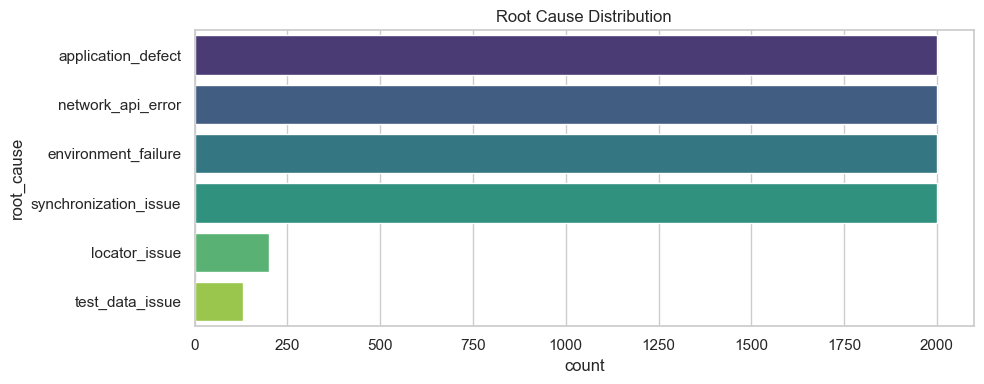

In [4]:
# Preprocess and filter classes
df = df.dropna(subset=["root_cause"])
df["root_cause"] = df["root_cause"].str.strip().str.lower()

VALID_CLASSES = [
    "locator_issue", "synchronization_issue", "test_data_issue",
    "environment_failure", "network_api_error", "application_defect"
]
df = df[df["root_cause"].isin(VALID_CLASSES)].reset_index(drop=True)

# Sample down-sampling for equal balancing (max 2000 per class)
dfs = []
for label in VALID_CLASSES:
    subset = df[df["root_cause"] == label]
    if len(subset) > 2000:
        subset = subset.sample(n=2000, random_state=42)
    dfs.append(subset)

df = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Filtered and down-sampled to {len(df):,} records.")

plt.figure(figsize=(10, 4))
sns.countplot(data=df, y="root_cause", order=df["root_cause"].value_counts().index, palette="viridis")
plt.title("Root Cause Distribution")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

We use **TF-IDF Vectorizers** for error messages and stack traces, **OrdinalEncoder** for the categories, and extract raw numeric parameters.

In [5]:
df["error_message"] = df["error_message"].fillna("").astype(str)
df["stack_trace"] = df["stack_trace"].fillna("").astype(str)
df["failure_stage"] = df["failure_stage"].fillna("unknown").astype(str)
df["severity"] = df["severity"].fillna("MEDIUM").astype(str)
df["failure_type"] = df["failure_type"].fillna("unknown").astype(str)

df["retry_count"] = pd.to_numeric(df["retry_count"], errors="coerce").fillna(0)
df["test_duration_sec"] = pd.to_numeric(df["test_duration_sec"], errors="coerce").fillna(30)
df["cpu_usage_pct"] = pd.to_numeric(df["cpu_usage_pct"], errors="coerce").fillna(50)
df["memory_usage_mb"] = pd.to_numeric(df["memory_usage_mb"], errors="coerce").fillna(1024)
df["is_flaky_test"] = df["is_flaky_test"].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int)

print("Text feature vectorization with TF-IDF...")
vec_msg = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_msg = vec_msg.fit_transform(df["error_message"])

vec_trace = TfidfVectorizer(max_features=200, ngram_range=(1, 2), sublinear_tf=True)
X_trace = vec_trace.fit_transform(df["stack_trace"])

print("Categorical ordinal encoding...")
cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
cat_cols = df[["failure_stage", "severity", "failure_type"]]
X_cat = cat_encoder.fit_transform(cat_cols)

numeric_cols = ["retry_count", "test_duration_sec", "cpu_usage_pct", "memory_usage_mb", "is_flaky_test"]
X_num = df[numeric_cols].values

X = hstack([X_msg, X_trace, csr_matrix(X_cat), csr_matrix(X_num)])
print(f"Feature matrix successfully constructed: {X.shape[0]} samples x {X.shape[1]} features.")

Text feature vectorization with TF-IDF...
Categorical ordinal encoding...
Feature matrix successfully constructed: 8330 samples x 708 features.


## 3. Encode Labels and Split Dataset

In [6]:
le = LabelEncoder()
y = le.fit_transform(df["root_cause"])
print(f"Encoded classes: {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Handle Class Imbalance using SMOTE
train_dist = Counter(y_train)
min_count = min(train_dist.values())

if min_count < 500:
    k = min(5, min_count - 1)
    if k >= 1:
        smote = SMOTE(random_state=42, k_neighbors=k)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print(f"SMOTE applied. New class counts: {Counter(y_train)}")
else:
    print("Classes are already balanced. Skipping SMOTE.")

Encoded classes: ['application_defect', 'environment_failure', 'locator_issue', 'network_api_error', 'synchronization_issue', 'test_data_issue']
Train set size: 6664 samples
Test set size: 1666 samples
SMOTE applied. New class counts: Counter({np.int64(1): 1600, np.int64(3): 1600, np.int64(0): 1600, np.int64(2): 1600, np.int64(4): 1600, np.int64(5): 1600})


## 4. Train Models

We evaluate multiple classification algorithms: **Random Forest**, **Gradient Boosting**, and a combined **Soft-Voting Ensemble** classifier.

In [7]:
print("Training Random Forest classifier...")
rf = RandomForestClassifier(
    n_estimators=50, max_depth=10,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {rf_acc:.4%}")

print("Training Gradient Boosting classifier...")
gb = GradientBoostingClassifier(
    n_estimators=50, max_depth=3,
    learning_rate=0.1, random_state=42
)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boosting Accuracy: {gb_acc:.4%}")

print("Training Soft-Voting Ensemble classifier...")
ensemble = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb)],
    voting="soft"
)
ensemble.fit(X_train, y_train)
ens_acc = accuracy_score(y_test, ensemble.predict(X_test))
print(f"Voting Ensemble Accuracy: {ens_acc:.4%}")

Training Random Forest classifier...


Random Forest Accuracy: 71.7287%
Training Gradient Boosting classifier...
Gradient Boosting Accuracy: 100.0000%
Training Soft-Voting Ensemble classifier...
Voting Ensemble Accuracy: 100.0000%


## 5. Evaluate Best Model

We pick the highest-performing algorithm and inspect the detailed classification metrics and confusion matrix.

Selected Best Model: GradientBoosting with 100.0000% accuracy

Classification Report:

                       precision    recall  f1-score   support

   application_defect       1.00      1.00      1.00       400
  environment_failure       1.00      1.00      1.00       400
        locator_issue       1.00      1.00      1.00        40
    network_api_error       1.00      1.00      1.00       400
synchronization_issue       1.00      1.00      1.00       400
      test_data_issue       1.00      1.00      1.00        26

             accuracy                           1.00      1666
            macro avg       1.00      1.00      1.00      1666
         weighted avg       1.00      1.00      1.00      1666



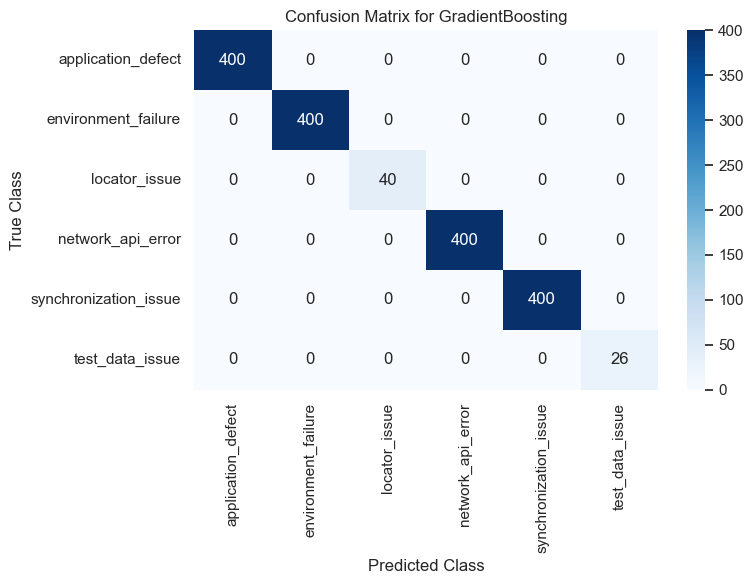

In [8]:
best_name, best_model, best_acc = max(
    [("RandomForest", rf, rf_acc),
     ("GradientBoosting", gb, gb_acc),
     ("Ensemble", ensemble, ens_acc)],
    key=lambda x: x[2]
)
print(f"Selected Best Model: {best_name} with {best_acc:.4%} accuracy")

y_pred = best_model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Compute & Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix for {best_name}")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()

## 6. Export Model Artifacts

Finally, serialize the trained components to the models folder so they can be loaded by the NEXTGEN QA inference services.

In [9]:
MODELS_DIR = os.path.join(BASE_DIR, "research", "models")
SERVICES_ML = os.path.join(BASE_DIR, "services", "ml-service", "models")

if not os.path.exists(MODELS_DIR):
    MODELS_DIR = os.path.join(BASE_DIR, "models")
if not os.path.exists(SERVICES_ML):
    SERVICES_ML = os.path.join(os.path.dirname(BASE_DIR), "services", "ml-service", "models")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SERVICES_ML, exist_ok=True)

artifacts = {
    "classifier.pkl": best_model,
    "vectorizer_msg.pkl": vec_msg,
    "vectorizer_trace.pkl": vec_trace,
    "cat_encoder.pkl": cat_encoder,
    "label_encoder.pkl": le
}

print("Exporting artifacts to research models directory...")
for fname, obj in artifacts.items():
    path = os.path.join(MODELS_DIR, fname)
    joblib.dump(obj, path, compress=3)
    print(f" - Saved {fname} ({os.path.getsize(path)//1024} KB)")

# Copy across to API microservice directory
print("\nCopying production-ready assets to ML microservice backend...")
for fname in artifacts.keys():
    src = os.path.join(MODELS_DIR, fname)
    dst = os.path.join(SERVICES_ML, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)

print("Completed. Model ready for NextGen QA deployment!")

Exporting artifacts to research models directory...
 - Saved classifier.pkl (78 KB)
 - Saved vectorizer_msg.pkl (5 KB)
 - Saved vectorizer_trace.pkl (2 KB)
 - Saved cat_encoder.pkl (0 KB)
 - Saved label_encoder.pkl (0 KB)

Copying production-ready assets to ML microservice backend...
Completed. Model ready for NextGen QA deployment!
